https://kaggle.com/competitions/california-house-prices

# 读取数据

In [22]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-notebook')
from matplotlib.ticker import StrMethodFormatter

C:\Users\David\AppData\Local\Temp\ipykernel_62448\2450131628.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-notebook')


In [7]:
train_path = "../data/california-house-prices/train.csv"
test_path = "../data/california-house-prices/test.csv"
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

train_data.head()

,Id,Address,Sold Price,Summary,Type,Year built,Heating,Cooling,Parking,Lot,...,Parking features,Tax assessed value,Annual tax amount,Listed On,Listed Price,Last Sold On,Last Sold Price,City,Zip,State
0,0,540 Pine Ln,3825000.0,"540 Pine Ln, Los Altos, CA 94022 is a single f...",SingleFamily,1969.0,"Heating - 2+ Zones, Central Forced Air - Gas","Multi-Zone, Central AC, Whole House / Attic Fan","Garage, Garage - Attached, Covered",1.0,...,"Garage, Garage - Attached, Covered",886486.0,12580.0,2019-10-24,4198000.0,NaN,NaN,Los Altos,94022,CA
1,1,1727 W 67th St,505000.0,"HURRY, HURRY.......Great house 3 bed and 2 bat...",SingleFamily,1926.0,Combination,"Wall/Window Unit(s), Evaporative Cooling, See ...","Detached Carport, Garage",4047.0,...,"Detached Carport, Garage",505000.0,6253.0,2019-10-16,525000.0,2019-08-30,328000.0,Los Angeles,90047,CA
2,2,28093 Pine Ave,140000.0,'THE PERFECT CABIN TO FLIP! Strawberry deligh...,SingleFamily,1958.0,Forced air,NaN,0 spaces,9147.0,...,NaN,49627.0,468.0,2019-08-25,180000.0,NaN,NaN,Strawberry,95375,CA
3,3,10750 Braddock Dr,1775000.0,Rare 2-story Gated 5 bedroom Modern Mediterran...,SingleFamily,1947.0,Central,Central Air,"Detached Carport, Driveway, Garage - Two Door",NaN,...,"Detached Carport, Driveway, Garage - Two Door",1775000.0,20787.0,2019-10-24,1895000.0,2016-08-30,1500000.0,Culver City,90230,CA
4,4,7415 O Donovan Rd,1175000.0,Beautiful 200 acre ranch land with several pas...,VacantLand,NaN,NaN,NaN,0 spaces,NaN,...,NaN,NaN,NaN,2019-06-07,1595000.0,2016-06-27,900000.0,Creston,93432,CA


In [8]:
train_data.shape, test_data.shape

((47439, 41), (31626, 40))

# 预处理数据

In [29]:
# 将特征分为数字特征和字符特征
numeric_features = train_data.dtypes[train_data.dtypes != 'object'].index
obj_features = train_data.dtypes[train_data.dtypes == 'object'].index

train_num = train_data[numeric_features]
train_obj = train_data[obj_features]

numeric_features

Index(['Id', 'Sold Price', 'Year built', 'Lot', 'Bathrooms', 'Full bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Elementary School Score', 'Elementary School Distance',
       'Middle School Score', 'Middle School Distance', 'High School Score',
       'High School Distance', 'Tax assessed value', 'Annual tax amount',
       'Listed Price', 'Last Sold Price', 'Zip'],
      dtype='object')

In [11]:
# 数字特征处理
print(train_num.shape)
print("------"*20)
print(train_num.columns)
print("------"*20)
print(train_num.info())
print("------"*20)
print(train_num.describe())
print("------"*20)

(47439, 20)
------------------------------------------------------------------------------------------------------------------------
Index(['Id', 'Sold Price', 'Year built', 'Lot', 'Bathrooms', 'Full bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Elementary School Score', 'Elementary School Distance',
       'Middle School Score', 'Middle School Distance', 'High School Score',
       'High School Distance', 'Tax assessed value', 'Annual tax amount',
       'Listed Price', 'Last Sold Price', 'Zip'],
      dtype='object')
------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47439 entries, 0 to 47438
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           47439 non-null  int64  
 1   Sold Price           

In [15]:
for numeric_feature in numeric_features:
    print(train_data[numeric_feature].value_counts())
    print("------"*20)

Id
0        1
31630    1
31621    1
31622    1
31623    1
        ..
15814    1
15815    1
15816    1
15817    1
47438    1
Name: count, Length: 47439, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Sold Price
1200000.0    360
1100000.0    355
1300000.0    317
1250000.0    313
850000.0     289
            ... 
1539999.0      1
2146320.0      1
296500.0       1
441500.0       1
2267500.0      1
Name: count, Length: 5627, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Year built
1973.0    828
2020.0    740
1950.0    733
1972.0    672
2006.0    671
         ... 
19.0        1
1878.0      1
1868.0      1
1852.0      1
9999.0      1
Name: count, Length: 164, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Lot
5000.0     422
6098.0     

In [18]:
# CORRELATION - NORMALITY - HOMOGENEITY 相关系数
corrPearson = train_num.corr(method="pearson")    # 两种相关系数定义方法
corrSpearman = train_num.corr(method="spearman")

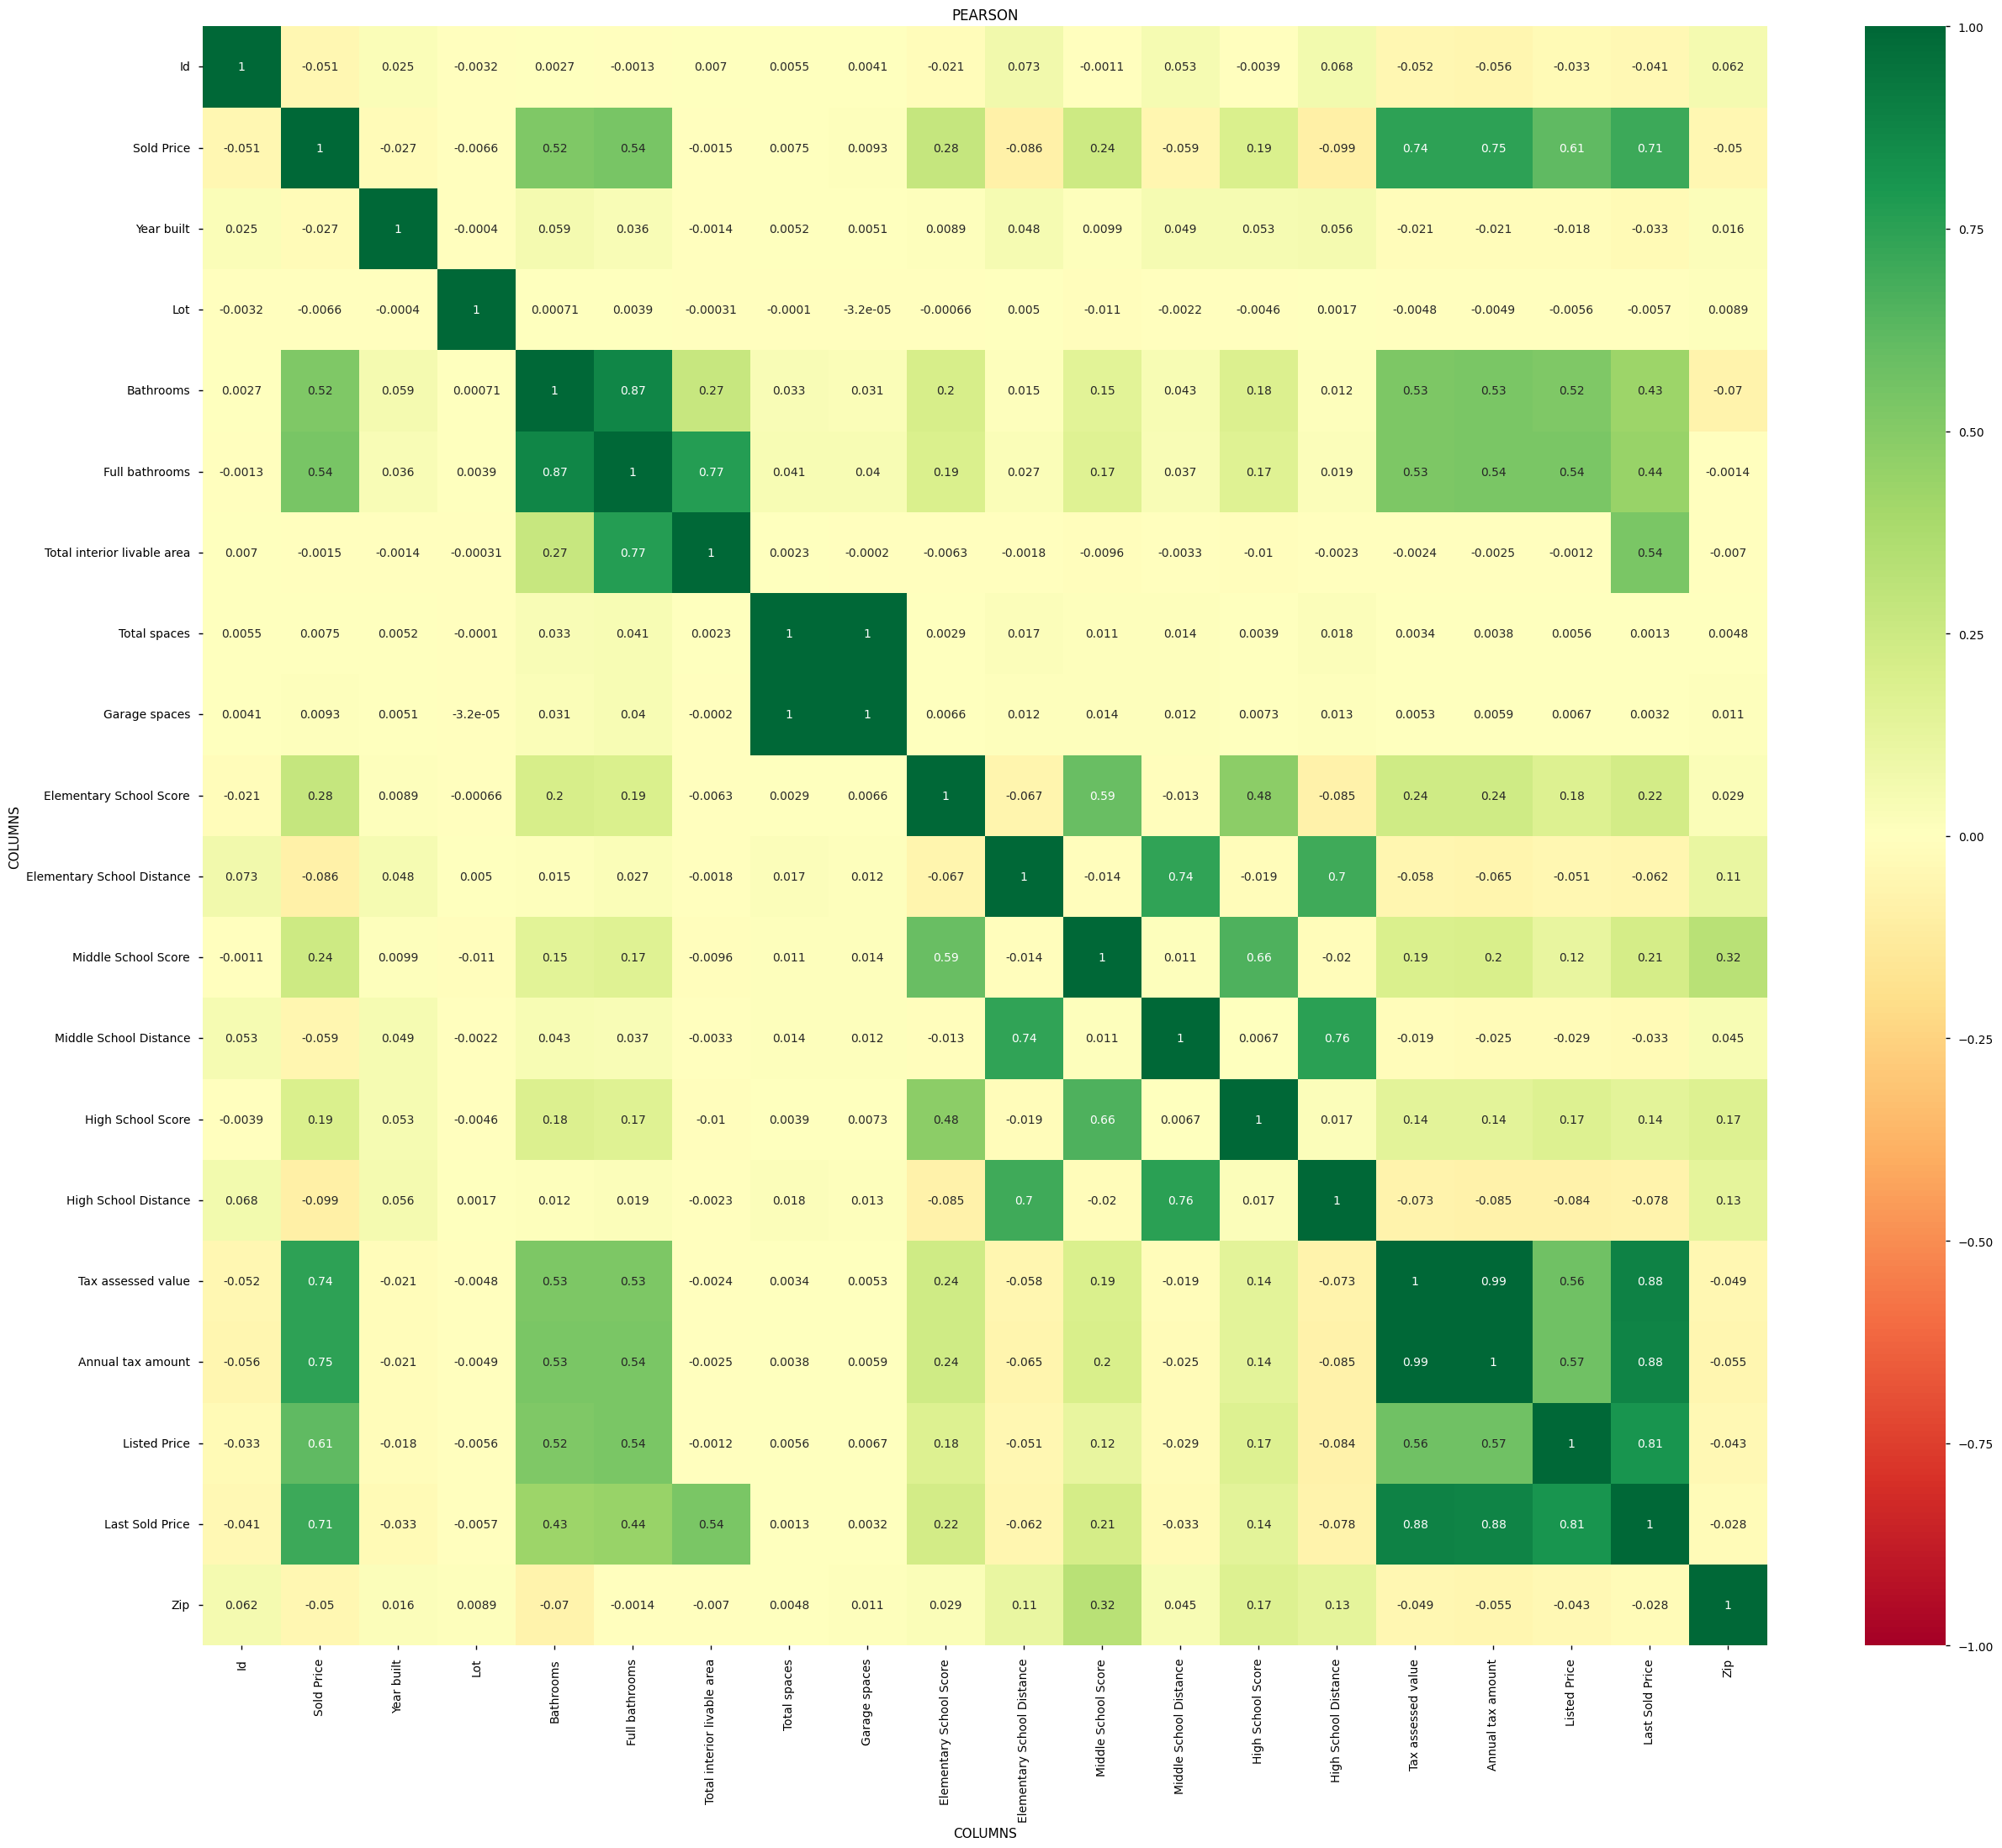

In [23]:
# PEARSON CORRELATION
figure = plt.figure(figsize=(30,25))
sns.heatmap(corrPearson,annot=True,cmap='RdYlGn', vmin=-1, vmax=+1)
plt.title("PEARSON")
plt.xlabel("COLUMNS")
plt.ylabel("COLUMNS")
plt.show()

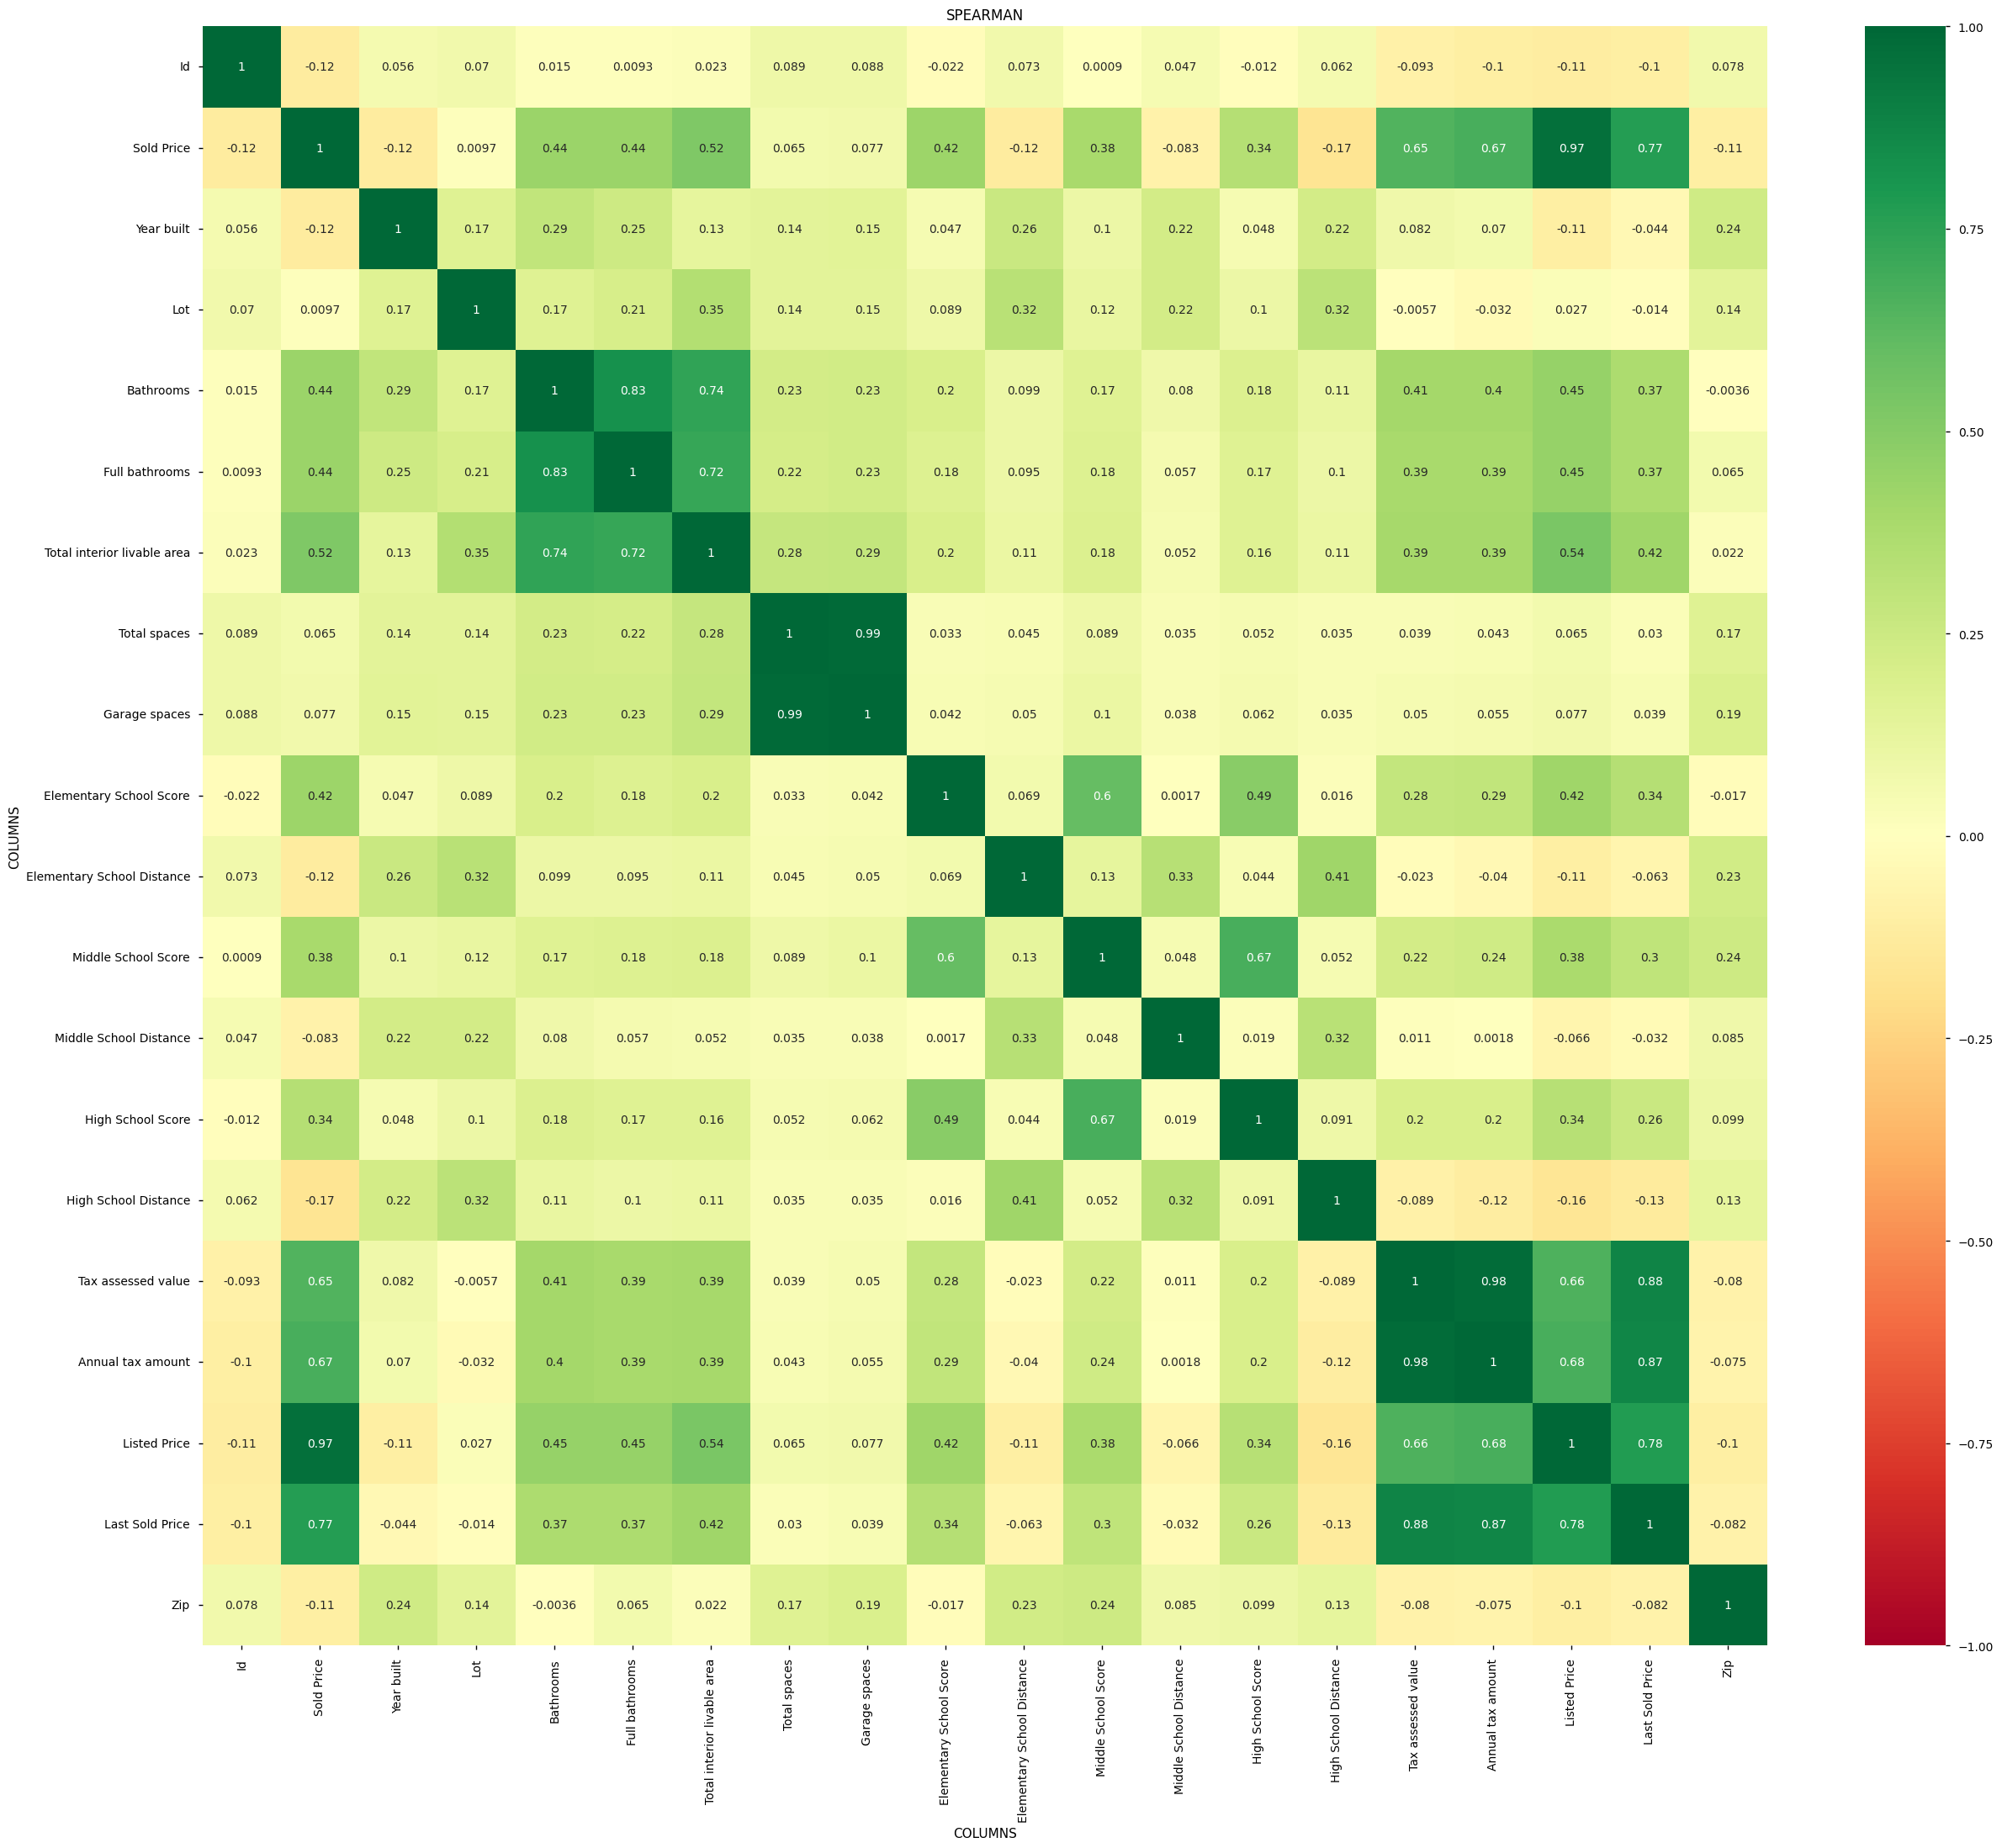

In [24]:
figure = plt.figure(figsize=(30,25))
sns.heatmap(corrSpearman,annot=True,cmap='RdYlGn', vmin=-1, vmax=+1)
plt.title("SPEARMAN")
plt.xlabel("COLUMNS")
plt.ylabel("COLUMNS")
plt.show()

CONCLUSION 结论

对于数值特征，Bathrooms, Full bathrooms, Tax assessed value, Annual tax amount, Listed Price, Last Sold Price具有较强正相关性; Elementary School Distance, Middle School Distance, High School Distance具有较强负相关性。

# 异常值(outliers)处理

In [25]:
main_num_features = ['Bathrooms', 'Full bathrooms', 'Tax assessed value', 'Annual tax amount', 'Listed Price', 'Last Sold Price']
for main_num_feature in main_num_features:
    print(train_data[main_num_feature].value_counts())
    print("------"*20)

Bathrooms
2.0     19594
3.0     11208
1.0      7863
4.0      2974
5.0       993
0.0       497
6.0       457
7.0       165
8.0        93
9.0        46
10.0       32
11.0       22
12.0       10
13.0        6
14.0        5
16.0        2
18.0        1
17.0        1
24.0        1
19.0        1
21.0        1
15.0        1
20.0        1
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Full bathrooms
2.0     21013
1.0      9432
3.0      6665
4.0      1603
5.0       496
6.0       203
7.0        65
8.0        48
9.0        22
10.0       10
11.0        9
12.0        4
17.0        1
14.0        1
15.0        1
13.0        1
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Tax assessed value
1224000.0    30
918000.0     27
867000.0     27
1200000.0    24
1530000.0    24
             ..
948192.0      1
6682

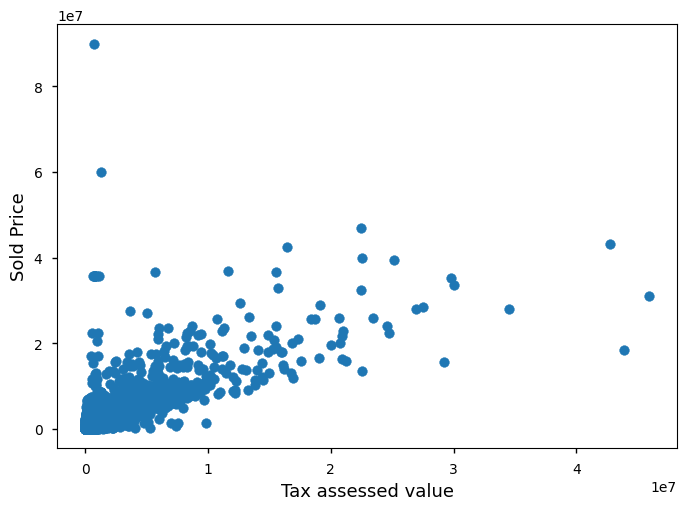

In [30]:
# Tax assessed value
fig, ax = plt.subplots()
ax.scatter(x = train_data['Tax assessed value'], y = train_data['Sold Price'])
plt.ylabel('Sold Price', fontsize=13)
plt.xlabel('Tax assessed value', fontsize=13)
plt.show()

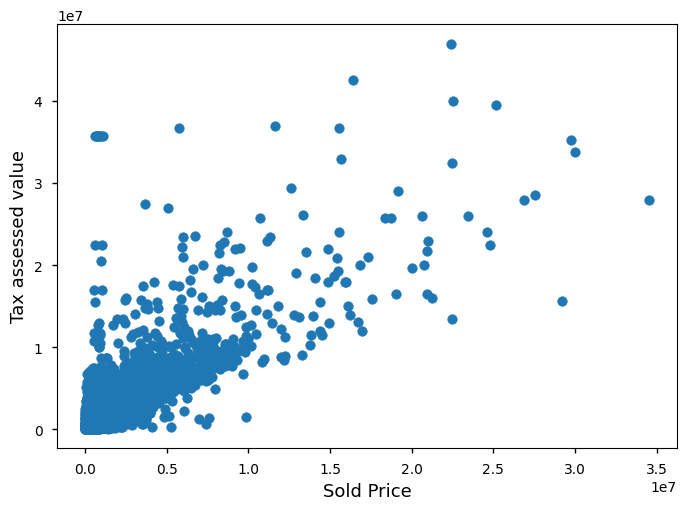

In [31]:
# Delete outliers
train_data = train_data.drop(train_data[(train_data['Tax assessed value'] > 4 * 10000000) | (train_data['Sold Price'] > 5 * 10000000)].index)

# Check plot again
fig, ax = plt.subplots()
ax.scatter(train_data['Tax assessed value'], train_data['Sold Price'])
plt.ylabel('Tax assessed value', fontsize=13)
plt.xlabel('Sold Price', fontsize=13)
plt.show()

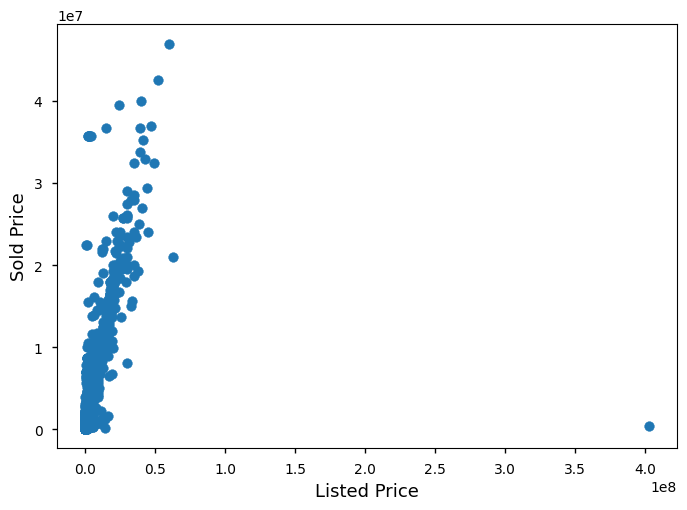

In [32]:
# Listed Price
fig, ax = plt.subplots()
ax.scatter(x = train_data['Listed Price'], y = train_data['Sold Price'])
plt.ylabel('Sold Price', fontsize=13)
plt.xlabel('Listed Price', fontsize=13)
plt.show()

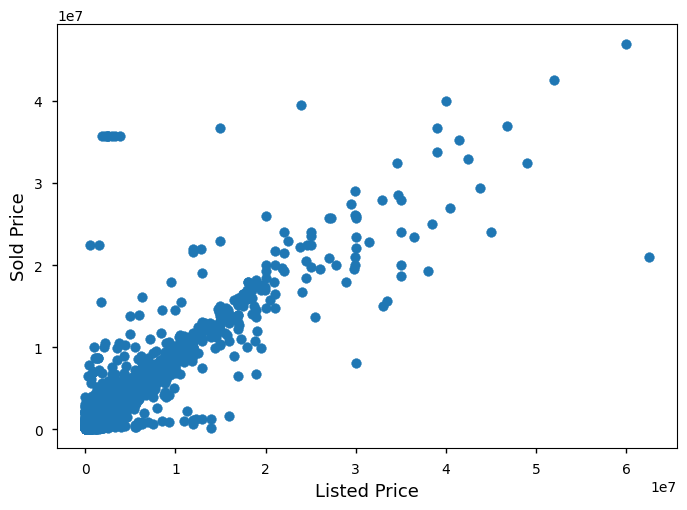

In [33]:
#Delete outliers
train_data = train_data.drop(train_data[(train_data['Listed Price']>2 * 100000000)].index)

#Check the graphic again
fig, ax = plt.subplots()
ax.scatter(train_data['Listed Price'], train_data['Sold Price'])
plt.ylabel('Sold Price', fontsize=13)
plt.xlabel('Listed Price', fontsize=13)
plt.show()

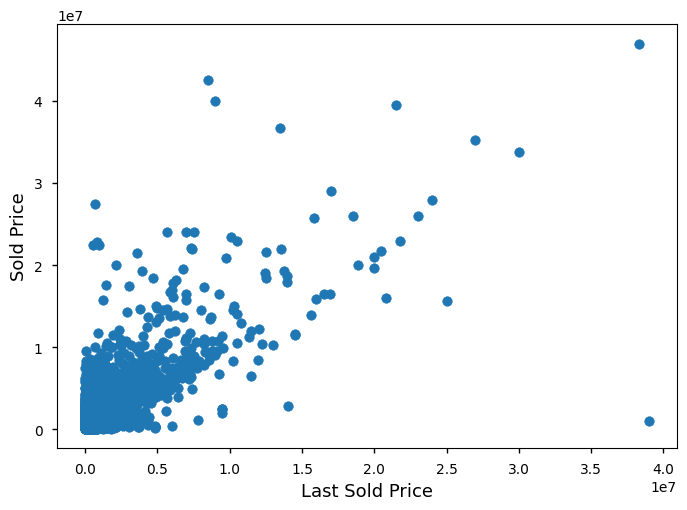

In [34]:
# Last Sold Price
fig, ax = plt.subplots()
ax.scatter(x = train_data['Last Sold Price'], y = train_data['Sold Price'])
plt.ylabel('Sold Price', fontsize=13)
plt.xlabel('Last Sold Price', fontsize=13)
plt.show()

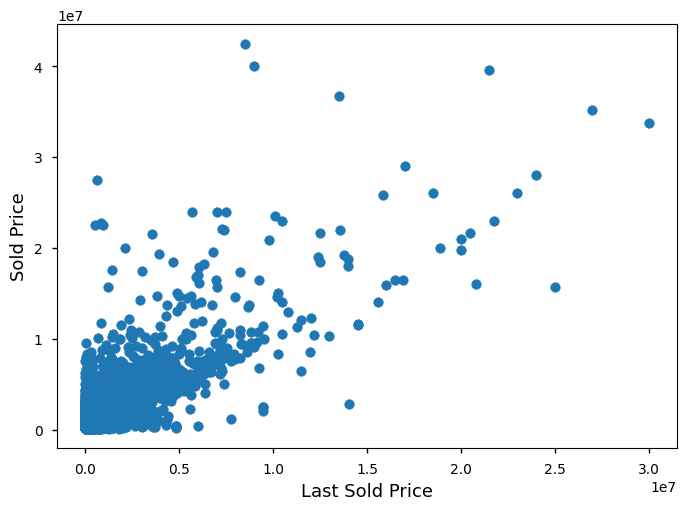

In [35]:
#Delete outliers
train_data = train_data.drop(train_data[(train_data['Last Sold Price']>3.5 * 10000000)].index)

#Check the graphic again
fig, ax = plt.subplots()
ax.scatter(train_data['Last Sold Price'], train_data['Sold Price'])
plt.ylabel('Sold Price', fontsize=13)
plt.xlabel('Last Sold Price', fontsize=13)
plt.show()

# 离散特征处理

In [26]:
print(train_obj.shape)
print("------"*20)
print(train_obj.columns)
print("------"*20)
print(train_obj.info())
print("------"*20)
print(train_obj.describe())
print("------"*20)

(47439, 21)
------------------------------------------------------------------------------------------------------------------------
Index(['Address', 'Summary', 'Type', 'Heating', 'Cooling', 'Parking',
       'Bedrooms', 'Region', 'Elementary School', 'Middle School',
       'High School', 'Flooring', 'Heating features', 'Cooling features',
       'Appliances included', 'Laundry features', 'Parking features',
       'Listed On', 'Last Sold On', 'City', 'State'],
      dtype='object')
------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47439 entries, 0 to 47438
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Address              47439 non-null  object
 1   Summary              47085 non-null  object
 2   Type                 47439 non-null  object
 3   Heating              40587 non

In [27]:
for obj_feature in obj_features:
    print(train_data[obj_feature].value_counts())
    print("------"*20)

Address
55 W 20th Ave               4
400 Mariners Island Blvd    3
1 Appian Way                3
425 N El Camino Real        3
555 Fulton St #428          2
                           ..
1200 N Las Palmas Ave       1
655 Glencrag Way            1
15920 La Escuela Ct         1
852 S Curson Ave            1
4552 Howard Ave             1
Name: count, Length: 47325, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Summary
Neighboring The Ace Hotel, 939 S. Broadway is the epitome of effort lessliving in Downtown Los Angeles. While the former Western Costume Building maintains its iconic exterior architecture, each residence has been renovated to feature the finest modern details. Stainless steel appliances and Quartz countertops add contemporary sophistication to the loft-style, industrial chic interiors. The original, towering windows, capture abundant natural light and reveal dynamic views of Downtown Lo

In [28]:
main_obj_features = ['Type', 'Cooling', 'Bedrooms', 'Region', 'Cooling features', 'City', 'State']

for main_obj_feature in main_obj_features:
    print(train_data[main_obj_feature].value_counts())
    print("------"*20)

Type
SingleFamily                     31324
Condo                             8094
Townhouse                         2545
Unknown                           1597
MultiFamily                       1292
                                 ...  
Detached                             1
Unit Below, 2 Level, Detached        1
Flat, Low-Rise (1-3)                 1
Mid-Rise (4-8), End Unit             1
Detached, 3 Story, Attached          1
Name: count, Length: 158, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Cooling
Central Air                                              8875
Central AC                                               6066
Central                                                  2756
Ceiling Fan                                              1137
Ceiling Fan, Central AC                                   901
                                                         ... 
Dual, Wall Unit(s)        

# 特征工程

In [36]:
# 合并训练集与测试集
ntrain = train_data.shape[0]
ntest = test_data.shape[0]
y_train = train_data['Sold Price'].values
all_features = main_num_features + main_obj_features

train_labels = torch.tensor(train_data['Sold Price'].values.reshape(-1, 1), dtype=torch.float32)

train_data1 = train_data[all_features]
test_data1 = test_data[all_features]
all_data = pd.concat((train_data1, test_data1)).reset_index(drop=True)
print("all_data size is : {}".format(all_data.shape))

all_data size is : (79057, 13)


空值填充

In [37]:
# 对于数值特征，用均值替代空值
all_data[main_num_features] = all_data[main_num_features].fillna(all_data[main_num_features].mean())

One-Hot

In [44]:
# 对于字符特征，使用独热编码
all_data = pd.get_dummies(all_data, dummy_na=True, dtype=int)
bool_cols = all_data.select_dtypes(include=['bool']).columns
all_data[bool_cols] = all_data[bool_cols].astype(int)
all_data.dtypes

Bathrooms             float64
Full bathrooms        float64
Tax assessed value    float64
Annual tax amount     float64
Listed Price          float64
                       ...   
City_Zenia              int32
City_nan                int32
State_AZ                int32
State_CA                int32
State_nan               int32
Length: 4349, dtype: object

In [46]:
all_data.dtypes.value_counts()

int32      4343
float64       6
Name: count, dtype: int64

In [45]:
n_train = train_data.shape[0]

train_features = torch.tensor(all_data[:n_train].values,
                                dtype=torch.float32)
test_features = torch.tensor(all_data[n_train:].values,
                                dtype=torch.float32)

In [47]:
# 定义网络模型
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 64), nn.ReLU(), nn.Linear(64, 1))
    return net

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 定义损失函数
loss = nn.MSELoss().to(device)

def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features.to(device)), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds.to(device)),
                           torch.log(labels.to(device))))
    return rmse.item()

In [63]:
# 定义训练函数
def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate, weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [64]:
# K折交叉验证
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

In [65]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        net.to(device)
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

折1，训练log rmse0.263601, 验证log rmse0.268294
折2，训练log rmse0.257179, 验证log rmse0.260673
折3，训练log rmse0.269582, 验证log rmse0.254704
折4，训练log rmse0.415276, 验证log rmse0.445221
折5，训练log rmse0.369752, 验证log rmse0.376024
5-折验证: 平均训练log rmse: 0.315078, 平均验证log rmse: 0.320983


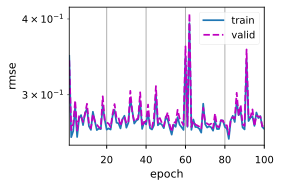

In [66]:
# 模型选择（确定超参数）
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.01, 0.001, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

In [70]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.01, 0.001, 64
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    net.to(device)
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features.to(device)).detach().cpu().numpy()
    preds = pd.Series(preds.reshape(1,-1)[0])
    return preds

训练log rmse：0.267968


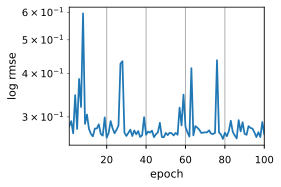

In [71]:
preds_1 = train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

In [72]:
test_data['Sold Price'] = preds_1
submission1 = pd.concat([test_data['Id'], test_data['Sold Price']], axis=1)
submission1.to_csv('submission.csv', index=False)
print('submission is saved!')

submission is saved!
